In [ ]:
import sys
import os
sys.path.append('../scripts/')
from analysis import PhenologyEDA
from functions import datenum_to_datetime
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import seaborn as sns
import netCDF4

In [ ]:
lakeid = 310
i , j = 31, 94

In [265]:
# version 3.1
pc_phenology_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\phenology\\phycocyanin\\{lakeid}.nc"
pc_extract_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\extract\\phycocyanin\\{lakeid}.nc"

chl_phenology_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\phenology\\chla\\{lakeid}.nc"
chl_extract_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\extract\\chla\\{lakeid}.nc"

In [266]:
PhenologyEDA.set_shapefile_path(r"C:\Users\schelian\Downloads\lakes_cci_v2.1.0_shp\shapefile\lakescci_v2.1.0_data-availability.shp")

In [267]:
# load classes
phyco_v3 = PhenologyEDA(pc_extract_path_v3, pc_phenology_path_v3)
chla_v3 = PhenologyEDA(chl_extract_path_v3, chl_phenology_path_v3)

## Interactive plotting

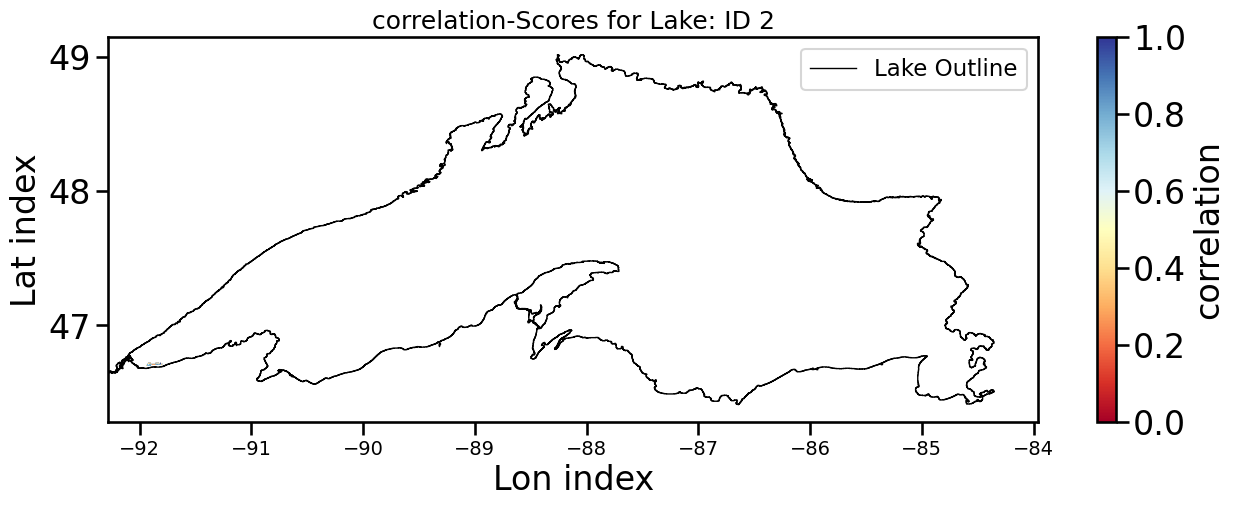

In [60]:
fig, ax = plt.subplots(1,1,figsize=(15,5))
phyco_v3.metric_map(phyco_v3.correlation_scores(),'correlation',fig,ax,'RdYlBu')

## Times series plots
Examples of how to edit plots

In [ ]:
# Implement a time series plot of the cubic spline and background data
fig, ax = plt.subplots(1,1,figsize=(15,5))

chla_v3.single_plot(i,j, ax, aggregation=False,start=2003, end= 2012)

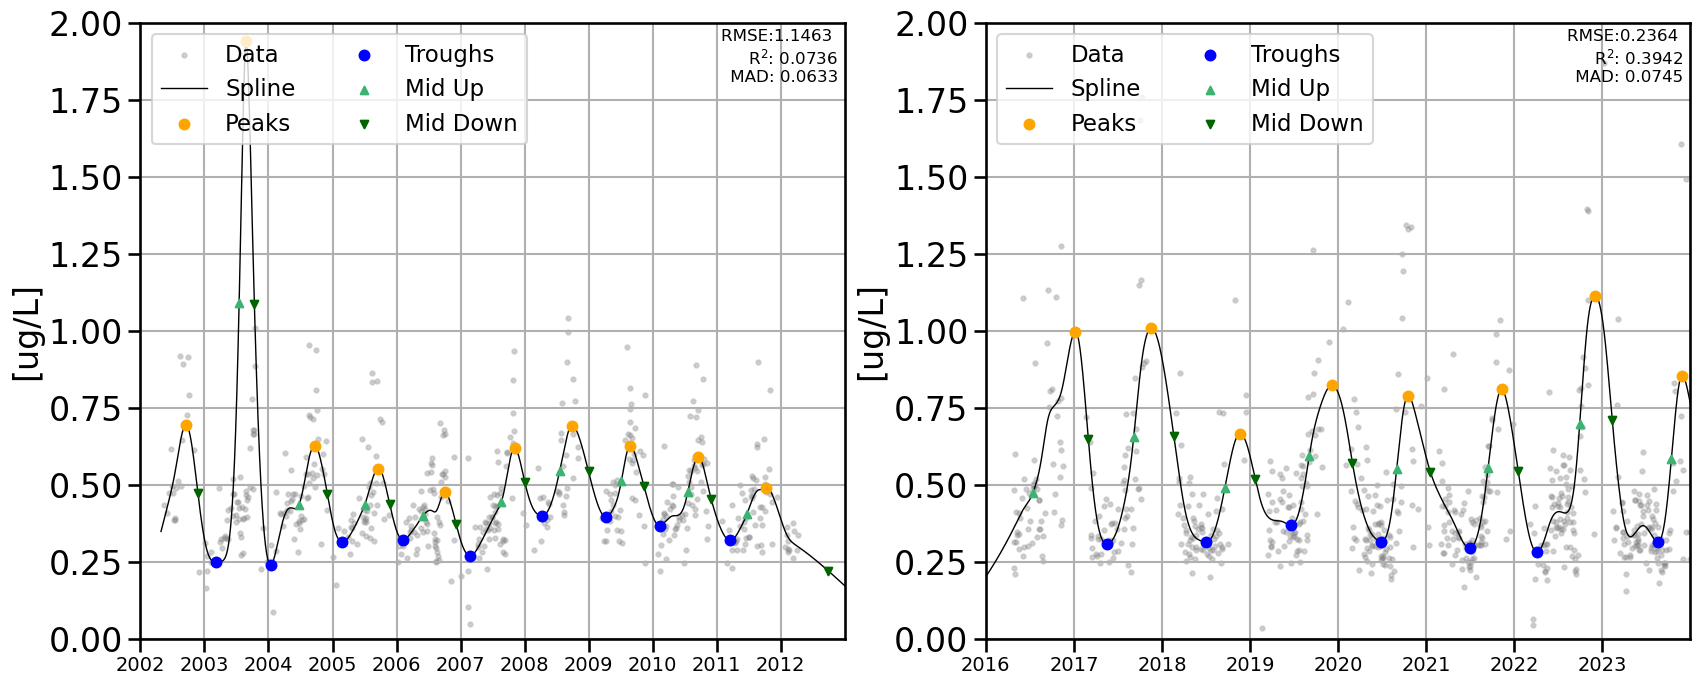

In [ ]:
# Implement a split plot with formatting edits after creation.
fig, axs = plt.subplots(1,2, figsize = (20,8))

chla_v3.split_plot(ax0 = axs[0], ax1=axs[1],latitude = i,longitude = j, aggregation=False,end0 = 2012,start1 = 2016)
axs[0].set_title("")
axs[1].set_title("")
axs[0].set_ylim(0,2)
axs[1].set_ylim(0,2)


axs[0].texts[0].set_fontsize(12)
axs[1].texts[0].set_fontsize(12)


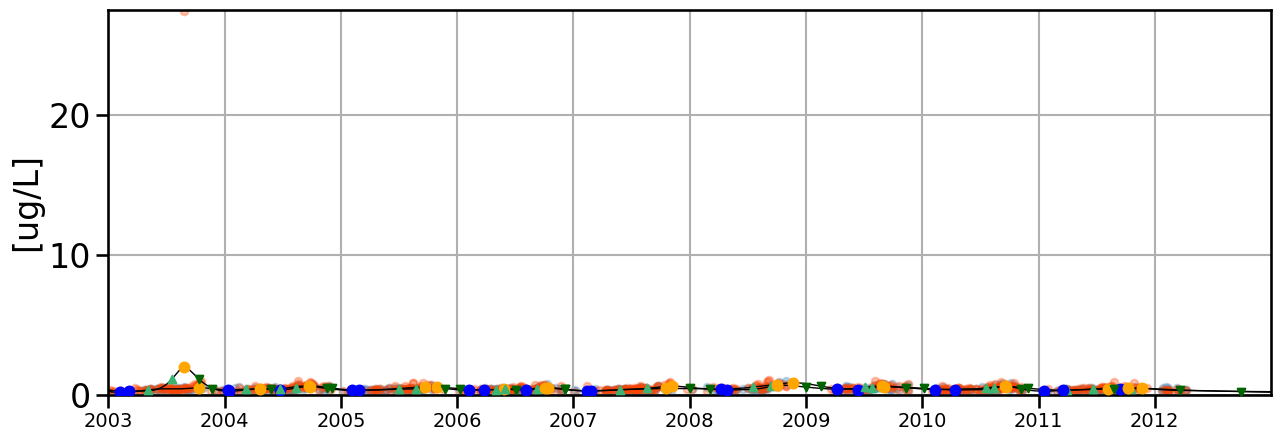

In [ ]:
# Plot the splines and data from two pixels on the same plot, with formatting edits.
fig, ax = plt.subplots(1,1,figsize=(15,5))

chla_v3.single_plot(137,312, ax, aggregation=False,start=2003, end= 2012)
ax.collections[0].set(color = 'steelblue')
ax.collections[0].set_sizes([30])
chla_v3.single_plot(155,306, ax, aggregation=False, start=2003,end= 2012)
ax.collections[-5].set(color = 'orangered',sizes=[30])
for txt in ax.texts:
    txt.remove()
ax.get_legend().remove()
# ax.set_ylim(0,27.5)
ax.set_title("")
ax.grid()

## Maps

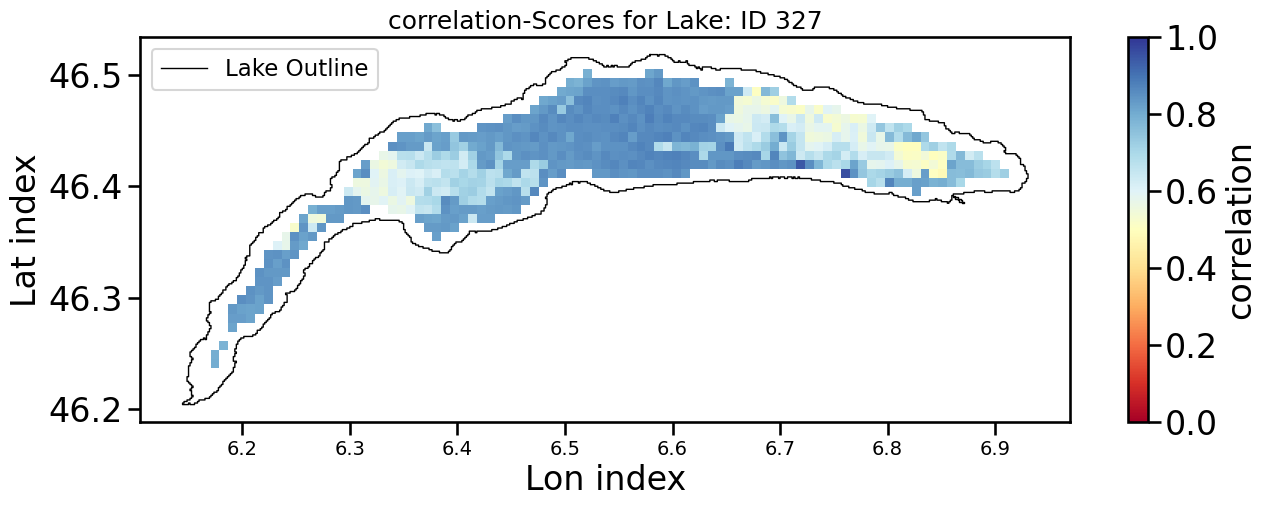

In [ ]:
# Plot a metric map
fig, ax = plt.subplots(1,1,figsize=(15,5))
phyco_v3.metric_map(phyco_v3.correlation_scores(),'correlation',fig,ax,'RdYlBu')

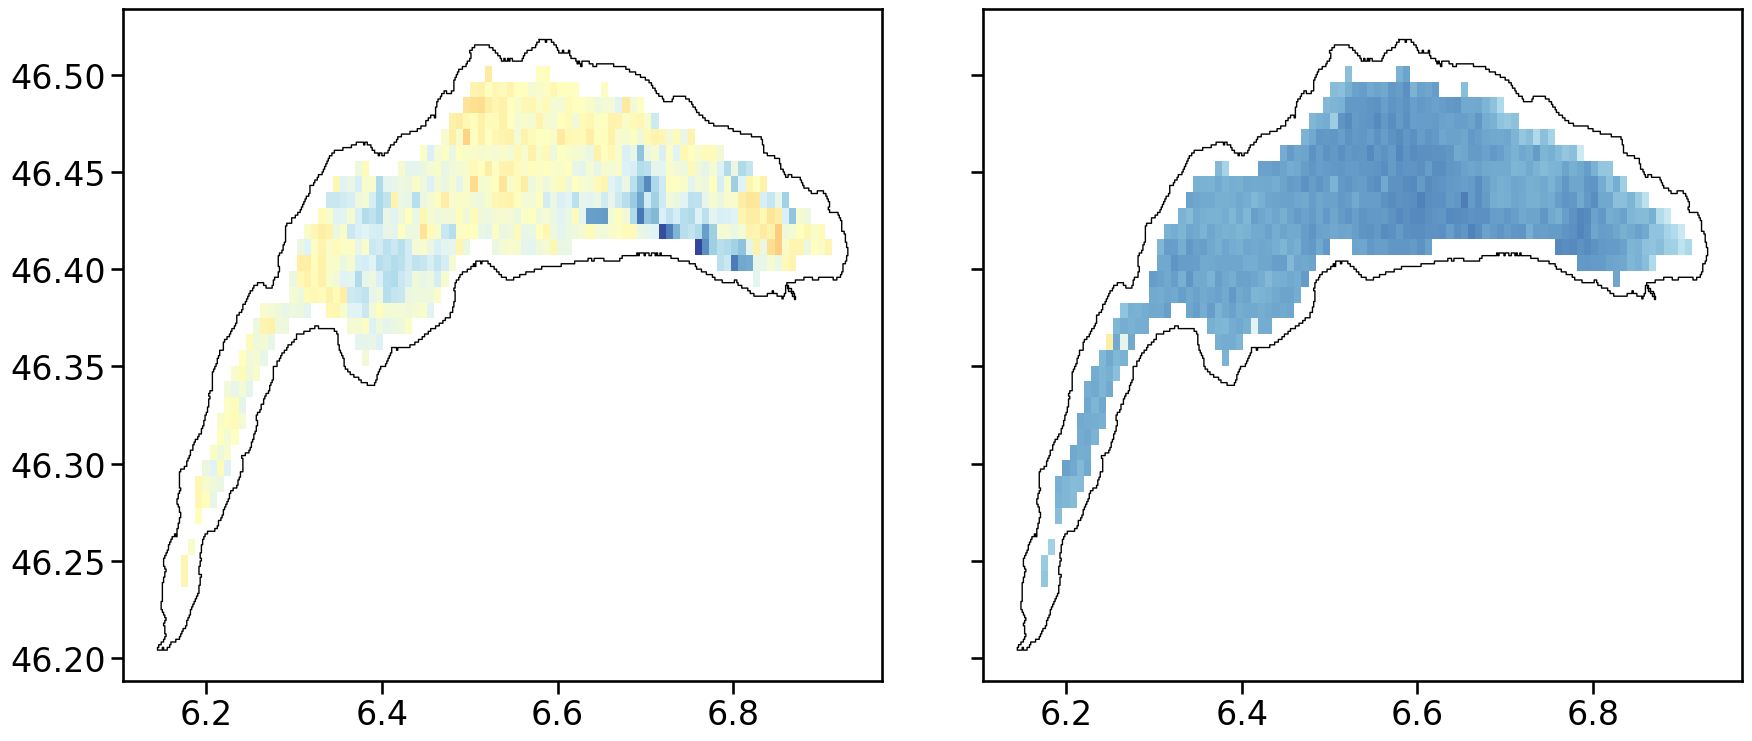

In [ ]:
# Plot two maps with formatting edits after map creation.
fig, axs = plt.subplots(1,2, figsize = (20,8))
cmap = 'RdYlBu'
colorbar_extent = [0,1]
phyco_v3.metric_map(phyco_v3.correlation_scores(end= 2012),'RMSE', fig, axs[0],cmap, colorbar_extent= colorbar_extent)
phyco_v3.metric_map(phyco_v3.correlation_scores(start= 2016),'RMSE', fig, axs[1],cmap, colorbar_extent= colorbar_extent)

fig.axes[-1].remove()
fig.axes[-1].remove()

axs[0].set_xlabel('')
axs[1].set_xlabel('')
axs[0].set_ylabel('')
axs[1].set_ylabel('')

axs[1].set_yticklabels([])
axs[0].get_legend().remove()
axs[1].get_legend().remove()
axs[0].set_title('')
axs[1].set_title('')
plt.tight_layout()

### Plotting a single day of data.
Move the code into the PhenologyEDA class

In [ ]:
bad_pixel_series = chla_v3.load_pixel_data(158,668)
bad_date = chla_v3._extracted_globals['t_all'][datenum_to_datetime(chla_v3._extracted_globals['t_all']) ==bad_pixel_series.idxmax()]
np.argwhere(datenum_to_datetime(chla_v3._extracted_globals['t_all']) ==bad_pixel_series.idxmax())

array([[258]])

In [ ]:
g = chla_v3._load_extracted_globals()
with netCDF4.Dataset(chla_v3.e_path) as nc:
                                values = np.array(nc.variables[g["variable"]][258, :, :])
                                qa     = np.array(nc.variables[g["qa"]][258, :, :])

mask = (values != -9999) & (qa == 0)

In [ ]:
lake_row = chla_v3.geom[chla_v3.geom["id"] == lakeid]
geom = lake_row.geometry.iloc[0]

shapely.geometry.multipolygon.MultiPolygon

Text(0.5, 1.0, '2003-08-25 00:00:00+00:00')

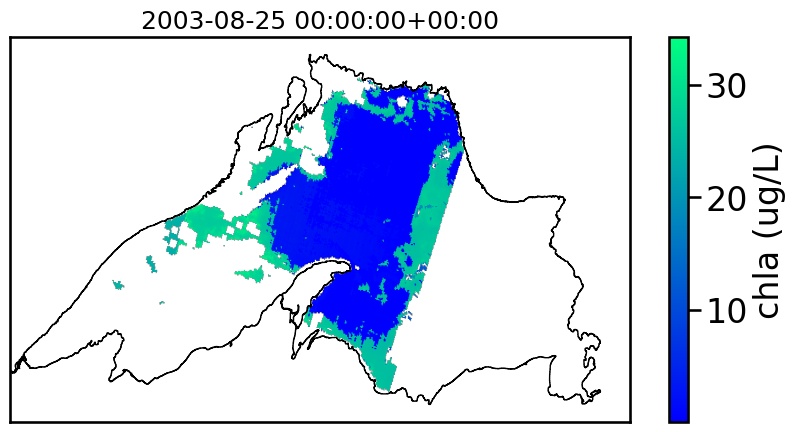

In [262]:
fig, ax = plt.subplots(1,1,figsize=(10,5))
with netCDF4.Dataset(chla_v3.e_path) as nc:
        summary = np.array(nc.variables["summary"][:, :])
        lats = nc.variables["lat"][:]
        lons = nc.variables["lon"][:]
        map_data = np.where(mask, values, np.nan)
        cmap = "winter"
        im = ax.imshow(map_data, cmap=cmap, aspect="auto", origin="lower", extent=[lons.min(), lons.max(), lats.min(), lats.max()])
        for poly in geom.geoms:
                        x, y = poly.exterior.xy
                        label = "Lake Outline" if not label else None
                        ax.plot(x, y, color="black", linewidth=1, label = label)
                        label = True
fig.colorbar(im,orientation='vertical',label='chla (ug/L)')
plt.xticks([])
plt.yticks([])
plt.title(datenum_to_datetime(bad_date).astype(str)[0])

## Comparative plots

In [ ]:

phyco_series = phyco_v3.load_pixel_data(i,j)
chla_series = chla_v3.load_pixel_data(i,j)
meris_sensor = chla_series.index.year < 2013

In [ ]:
df_to_plot = pd.concat([chla_series,phyco_series],axis=1)
df_to_plot.columns = ['chla','phyco']
df_to_plot['year'] = df_to_plot.index.year
df_to_plot['meris_period'] = df_to_plot['year'] < 2013

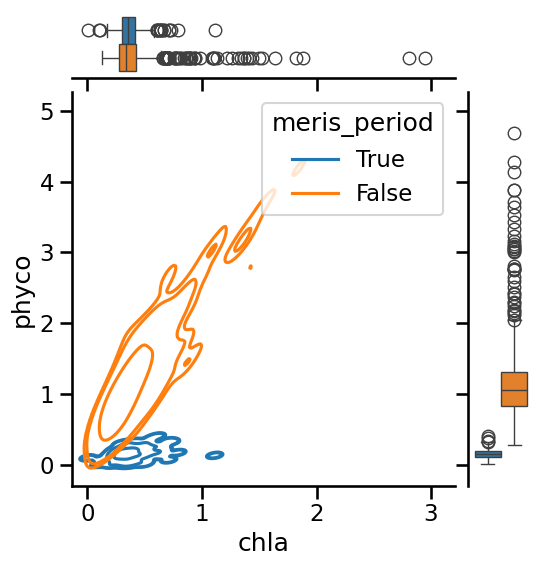

In [ ]:
sns.set_context("talk")
g = sns.JointGrid(df_to_plot, x= "chla",y="phyco",hue="meris_period",hue_order=[True,False],height=6)
g.plot_joint(sns.kdeplot,levels=[0.005,0.01,0.1,0.5])
g.plot_marginals(sns.boxplot)